# 🚦 SynapseSignal — Dev 1: Vehicle Detection & Classification

**Pipeline flow via Gemini Vision API:**
```
Frame
 ↓
Gemini 2.5 Flash API (Zero-Shot Detection)
 ↓
Unified Detection:
  ├── Normal Vehicles    → parsed as 'normal_vehicle' (feeds Dev 2 congestion)
  └── Emergency Vehicles → parsed as 'emergency_vehicle' + subtype
 ↓
Structured JSON payload
```


## 📦 Cell 1 — Imports & Construct API Pipeline

*(Make sure you have run `pip install -r requirements.txt` before running this notebook)*

In [1]:
from google import genai
from google.genai import types
import supervision as sv
import cv2
import json
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Dict, Any, Tuple
from dotenv import load_dotenv

# ─── 0. Load Environment Variables ────────────────────────────────────────
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY not found. Please create a .env file with GEMINI_API_KEY=your_key_here")

# ─── 1. Authenticate to Gemini ────────────────────────────────────────────────
client = genai.Client(api_key=GEMINI_API_KEY)
print("✅ Connected to Gemini API!")

# ─── 2. Annotators & State ────────────────────────────────────────────────────
label_annotator = sv.LabelAnnotator()
bounding_box_annotator = sv.BoxAnnotator()

# FREE TIER RATE LIMITER STATE
LAST_API_CALL_TIME = 0.0
MIN_SECONDS_BETWEEN_CALLS = 4.1

# Schema dict specifying exactly what JSON shape we need back from Gemini
detection_schema = {
    "type": "OBJECT",
    "properties": {
        "vehicles": {
            "type": "ARRAY",
            "items": {
                "type": "OBJECT",
                "properties": {
                    "vehicle_type": {
                        "type": "STRING",
                        "description": "Must be exactly 'normal_vehicle' or 'emergency_vehicle'"
                    },
                    "subtype": {
                        "type": "STRING",
                        "description": "If emergency_vehicle, must be 'ambulance', 'fire_truck', or 'police'. If normal_vehicle, use 'none'."
                    },
                    "bbox_2d": {
                        "type": "ARRAY",
                        "items": {"type": "INTEGER"},
                        "description": "Bounding box [ymin, xmin, ymax, xmax] coordinates normalized from 0 to 1000. E.g., [100, 200, 300, 400] means ymin=0.1, xmin=0.2, etc. (ymin is top, xmin is left, ymax is bottom, xmax is right)."
                    }
                },
                "required": ["vehicle_type", "subtype", "bbox_2d"]
            }
        }
    },
    "required": ["vehicles"]
}

# ─── 3. Pipeline Frame Processor ──────────────────────────────────────────────
def process_frame(
    frame: np.ndarray,
) -> Tuple[List[Dict[str, Any]], sv.Detections, List[str]]:
    """Process a frame via cloud API, parse emergency vs normal vehicles."""
    global LAST_API_CALL_TIME

    if frame is None or frame.size == 0:
        return [], sv.Detections(xyxy=np.empty((0, 4)), class_id=np.empty((0,))), []
        
    pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    h, w = frame.shape[:2]
    
    # Enforce Rate Limiting (Throttle)
    time_since_last_call = time.time() - LAST_API_CALL_TIME
    if time_since_last_call < MIN_SECONDS_BETWEEN_CALLS:
        sleep_time = MIN_SECONDS_BETWEEN_CALLS - time_since_last_call
        print(f"⏳ Rate limiter active: Sleeping for {sleep_time:.2f}s to avoid Gemini billing...")
        time.sleep(sleep_time)

    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[
                "Analyze this traffic image. CRITICAL OBJECTIVE: You MUST search for and distinctly bound any emergency vehicles (ambulance, fire_truck, police car) present. Put emergency vehicles first in your output list. Then, detect the other normal vehicles around it. For each vehicle, provide its bounding box and classify it.",
                pil_img
            ],
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=detection_schema,
                temperature=0.1,
            ),
        )
        LAST_API_CALL_TIME = time.time()
        result = json.loads(response.text)
    except Exception as e:
        print(f"Gemini API Error: {e}")
        return [], sv.Detections(xyxy=np.empty((0, 4)), class_id=np.empty((0,))), []

    vehicles = result.get("vehicles", [])
    if not vehicles:
        return [], sv.Detections(xyxy=np.empty((0, 4)), class_id=np.empty((0,))), []

    xyxy, class_ids, confidences, labels, output = [], [], [], [], []
    
    for idx, v in enumerate(vehicles):
        v_type = v.get("vehicle_type", "normal_vehicle")
        subtype = v.get("subtype", "none")
        bbox_1000 = v.get("bbox_2d", [-1, -1, -1, -1])
        
        if len(bbox_1000) != 4 or bbox_1000[0] == -1:
            continue
            
        ymin, xmin, ymax, xmax = [val / 1000.0 for val in bbox_1000]
        y1, x1, y2, x2 = int(ymin * h), int(xmin * w), int(ymax * h), int(xmax * w)
        
        xyxy.append([x1, y1, x2, y2])
        class_ids.append(idx)
        confidences.append(0.99) # Placeholder confidence for Gemini
        
        is_emergency = (v_type == "emergency_vehicle")
        
        if is_emergency:
            labels.append(subtype)
            output.append({
                "type": "emergency_vehicle",
                "subtype": subtype,
                "subtype_confidence": 0.99,
                "bbox": [x1, y1, x2, y2],
                "confidence": 0.99,
            })
        else:
            labels.append("vehicle")
            output.append({
                "type": "normal_vehicle",
                "confidence": 0.99,
                "bbox": [x1, y1, x2, y2]
            })

    if not xyxy:
        return [], sv.Detections(xyxy=np.empty((0, 4)), class_id=np.empty((0,))), []
        
    detections = sv.Detections(
        xyxy=np.array(xyxy),
        confidence=np.array(confidences),
        class_id=np.array(class_ids)
    )
    
    return output, detections, labels

def get_dev2_payload(frame: np.ndarray) -> Dict[str, Any]:
    """API payload for Dev 2 (density tracker)."""
    detections, _, _ = process_frame(frame)
    return {
        "normal_vehicles":    [d for d in detections if d["type"] == "normal_vehicle"],
        "emergency_vehicles": [d for d in detections if d["type"] == "emergency_vehicle"],
    }


✅ Connected to Gemini API!


## 🚀 Cell 2 — Run Pipeline on Test Image

Testing on the local image in your workspace.

Processing image...


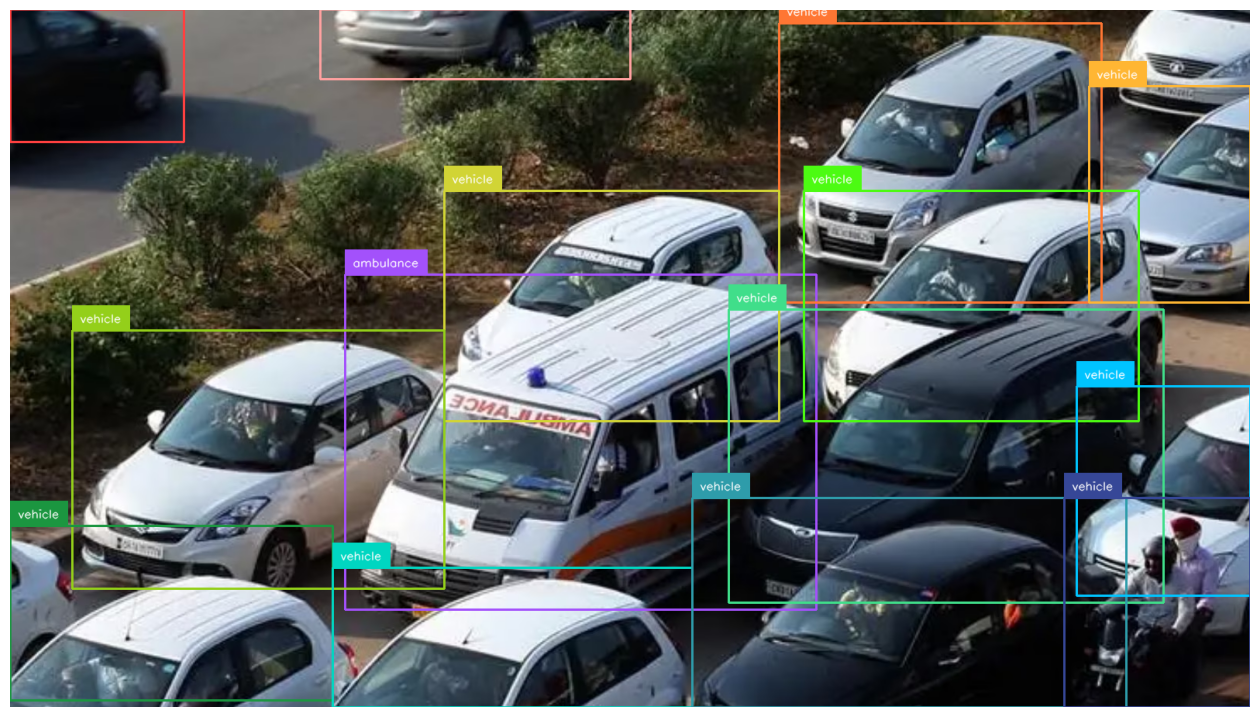


Total vehicles detected: 14
  Normal vehicles:    13
  Emergency vehicles: 1

📦 JSON Payload Structure For Dev 2:
⏳ Rate limiter active: Sleeping for 3.60s to avoid Gemini billing...


{
  "normal_vehicles_count": 11,
  "emergency_vehicles_count": 1,
  "sample_normal": [
    {
      "type": "normal_vehicle",
      "confidence": 0.99,
      "bbox": [
        0,
        0,
        224,
        162
      ]
    }
  ],
  "sample_emergency": [
    {
      "type": "emergency_vehicle",
      "subtype": "ambulance",
      "subtype_confidence": 0.99,
      "bbox": [
        432,
        342,
        1056,
        783
      ],
      "confidence": 0.99
    }
  ]
}


In [2]:
# Relative path to the image in your local workspace folder structure
YOUR_IMAGE = r"..\Dev1 pipeline\img with emergency.avif"

if not os.path.exists(YOUR_IMAGE):
    print(f"❌ Image not found at {YOUR_IMAGE}. Try fixing the path.")
else:
    print("Processing image...")
    if YOUR_IMAGE.lower().endswith('.avif'):
        import pillow_avif
        from PIL import Image
        pil_img = Image.open(YOUR_IMAGE).convert('RGB')
        image = np.array(pil_img)[:, :, ::-1].copy()
    else:
        image = cv2.imread(YOUR_IMAGE)

    output_json, detections, labels = process_frame(image)
    
    if len(detections) > 0:
        annotated_image = bounding_box_annotator.annotate(
            scene=image.copy(), detections=detections)
        annotated_image = label_annotator.annotate(
            scene=annotated_image, detections=detections, labels=labels)
            
        # For local script plotting:
        plt.figure(figsize=(16, 16))
        plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
    else:
        print("No detections found!")

    print(f'\nTotal vehicles detected: {len(output_json)}')
    normal_dets    = [d for d in output_json if d['type'] == 'normal_vehicle']
    emergency_dets = [d for d in output_json if d['type'] == 'emergency_vehicle']
    print(f'  Normal vehicles:    {len(normal_dets)}')
    print(f'  Emergency vehicles: {len(emergency_dets)}')

    print('\n📦 JSON Payload Structure For Dev 2:')
    payload = get_dev2_payload(image)
    print(json.dumps({
        'normal_vehicles_count':    len(payload['normal_vehicles']),
        'emergency_vehicles_count': len(payload['emergency_vehicles']),
        'sample_normal':    payload['normal_vehicles'][:1] if payload['normal_vehicles'] else [],
        'sample_emergency': payload['emergency_vehicles'][:1] if payload['emergency_vehicles'] else [],
    }, indent=2))